In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Upload CSV
uploaded = files.upload()

# Load dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")

print("Shape:", df.shape)
print(df.head())

# Prepare data
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["PlacementStatus"])

X = df.drop(columns=["PlacementStatus", "CGPA_Tier"])
y = df["PlacementStatus"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)

feature_names = preprocessor.get_feature_names_out()

print("Training:", X_train_p.shape)
print("Validation:", X_val_p.shape)

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset (1).csv
Shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  

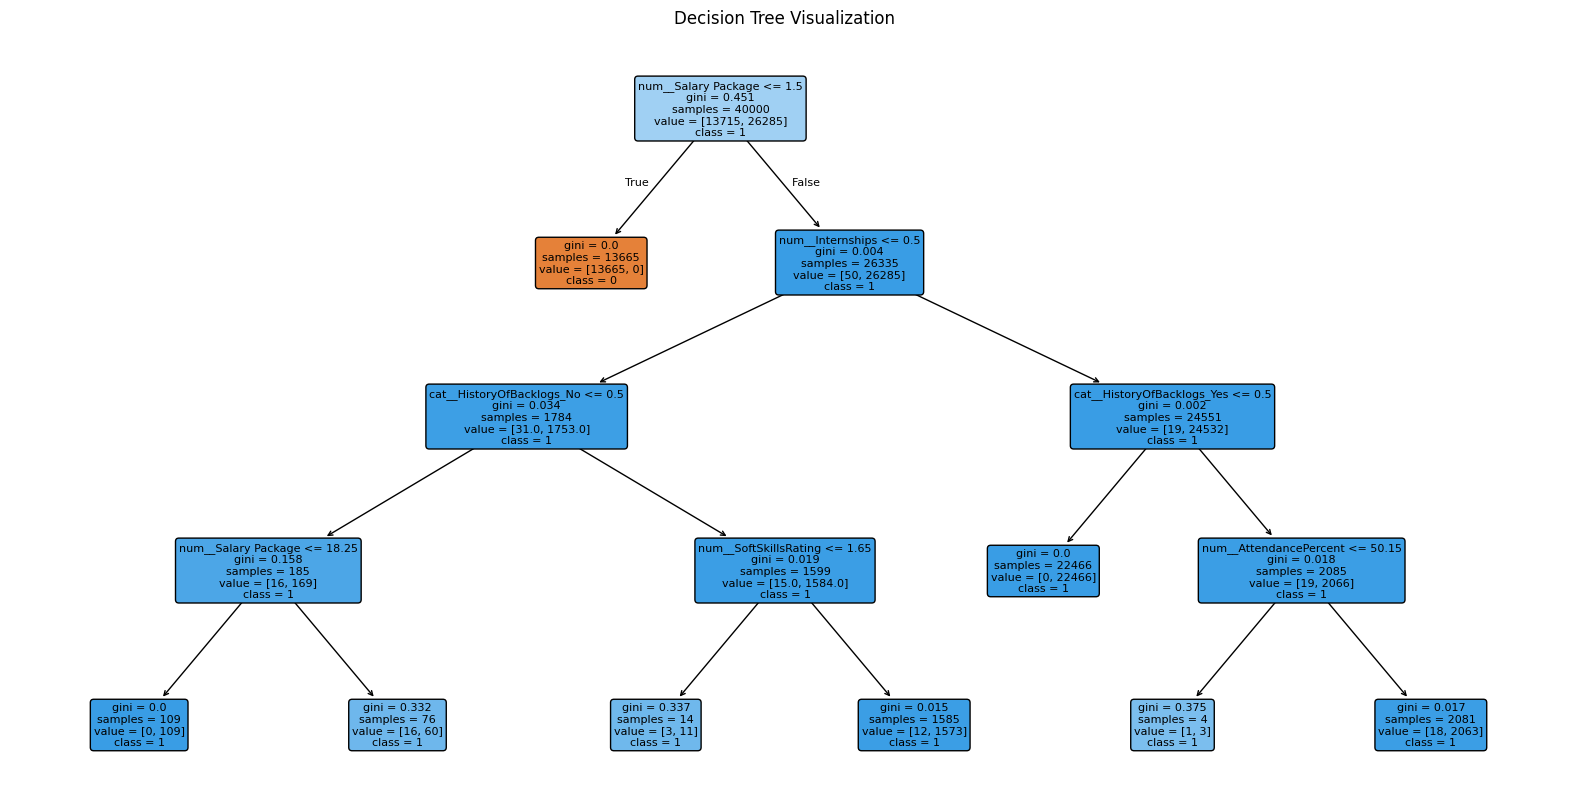

In [ ]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

model.fit(X_train_p, y_train)

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=[str(c) for c in model.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
results = []

for criterion in ["gini", "entropy"]:

    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    model.fit(X_train_p, y_train)

    train_acc = model.score(X_train_p, y_train)
    val_acc = model.score(X_val_p, y_val)

    results.append({
        "Criterion": criterion,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc
    })

comparison = pd.DataFrame(results)
print(comparison)

  Criterion  Train Accuracy  Validation Accuracy
0      gini             1.0               0.9963
1   entropy             1.0               0.9971


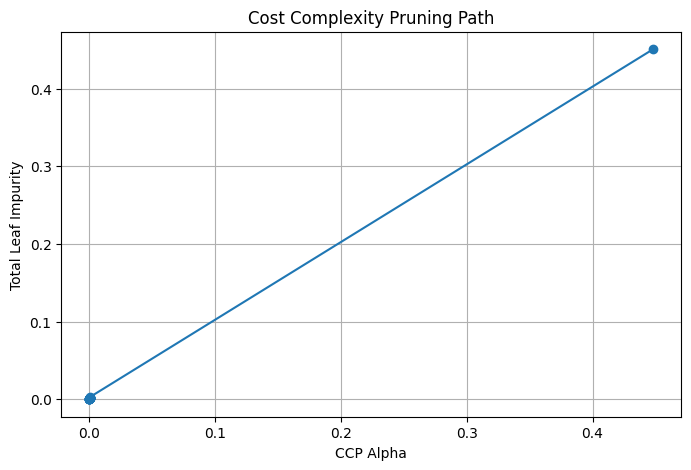

CCP Alphas:
[0.00000000e+00 1.66170635e-05 2.42063492e-05 2.44094488e-05
 2.44186047e-05 2.48380130e-05 3.14007318e-05 3.22794974e-05
 3.33333333e-05 3.44246668e-05 3.75000000e-05 4.03846154e-05
 4.37500000e-05 4.55813953e-05 4.91689798e-05 6.12500000e-05
 6.22240803e-05 7.60831242e-05 4.48128215e-01]


In [ ]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train_p, y_train)

path = model.cost_complexity_pruning_path(
    X_train_p, y_train
)

ccp_alphas = path.ccp_alphas

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas, path.impurities, marker="o")

plt.xlabel("CCP Alpha")
plt.ylabel("Total Leaf Impurity")
plt.title("Cost Complexity Pruning Path")
plt.grid()
plt.show()

print("CCP Alphas:")
print(ccp_alphas)

   Depth  Train Accuracy  Validation Accuracy
0      1        0.998750               0.9982
1      2        0.998750               0.9982
2      3        0.998750               0.9982
3      4        0.998750               0.9982
4      5        0.998775               0.9981
5      6        0.999000               0.9977
6      7        0.999175               0.9977
7      8        0.999250               0.9976
8      9        0.999450               0.9968
9     10        0.999600               0.9972
10  None        1.000000               0.9963


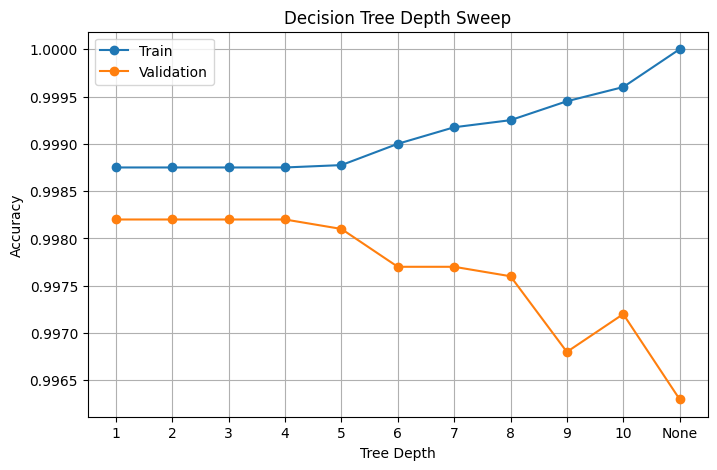

In [ ]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_p, y_train)

    results.append({
        "Depth": str(depth),
        "Train Accuracy": model.score(X_train_p, y_train),
        "Validation Accuracy": model.score(X_val_p, y_val)
    })

depth_df = pd.DataFrame(results)

print(depth_df)

plt.figure(figsize=(8, 5))
plt.plot(depth_df["Depth"], depth_df["Train Accuracy"],
         marker="o", label="Train")

plt.plot(depth_df["Depth"], depth_df["Validation Accuracy"],
         marker="o", label="Validation")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth Sweep")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def dt_report(X_train, y_train, X_val, y_val):

    results = []

    for criterion in ["gini", "entropy"]:

        for depth in [1, 3, 5, 10, None]:

            model = DecisionTreeClassifier(
                criterion=criterion,
                max_depth=depth,
                random_state=42
            )

            model.fit(X_train, y_train)

            train_acc = model.score(X_train, y_train)
            val_acc = model.score(X_val, y_val)

            results.append({
                "Criterion": criterion,
                "Depth": str(depth),
                "Train Accuracy": train_acc,
                "Validation Accuracy": val_acc,
                "Leaves": model.get_n_leaves(),
                "Tree Depth": model.get_depth()
            })

    return pd.DataFrame(results)


report = dt_report(
    X_train_p, y_train,
    X_val_p, y_val
)

print(report)

  Criterion Depth  Train Accuracy  Validation Accuracy  Leaves  Tree Depth
0      gini     1        0.998750               0.9982       2           1
1      gini     3        0.998750               0.9982       5           3
2      gini     5        0.998775               0.9981      13           5
3      gini    10        0.999600               0.9972      50          10
4      gini  None        1.000000               0.9963      74          15
5   entropy     1        0.998750               0.9982       2           1
6   entropy     3        0.998750               0.9982       5           3
7   entropy     5        0.998750               0.9982      10           5
8   entropy    10        0.999425               0.9974      36          10
9   entropy  None        1.000000               0.9971      53          16


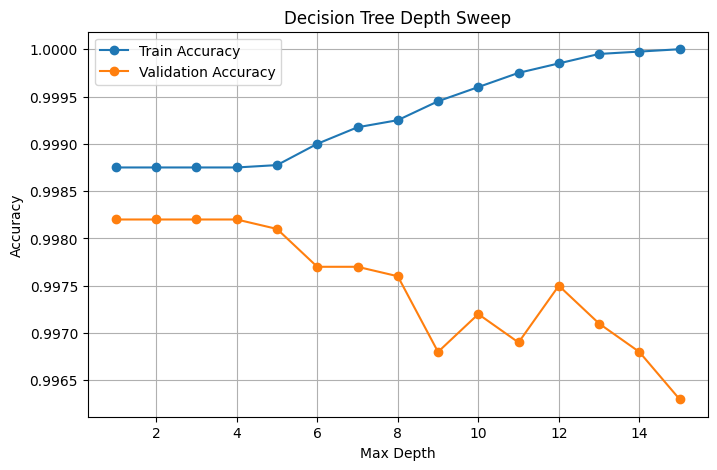

Best Depth Result:
depth        1.00000
train_acc    0.99875
val_acc      0.99820
n_leaves     2.00000
Name: 0, dtype: float64
    depth  train_acc  val_acc  n_leaves
0       1   0.998750   0.9982         2
1       2   0.998750   0.9982         3
2       3   0.998750   0.9982         5
3       4   0.998750   0.9982         8
4       5   0.998775   0.9981        13
5       6   0.999000   0.9977        20
6       7   0.999175   0.9977        25
7       8   0.999250   0.9976        32
8       9   0.999450   0.9968        41
9      10   0.999600   0.9972        50
10     11   0.999750   0.9969        60
11     12   0.999850   0.9975        68
12     13   0.999950   0.9971        72
13     14   0.999975   0.9968        73
14     15   1.000000   0.9963        74


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

def dt_report(X_train, y_train, X_val, y_val):

    results = []

    for depth in range(1, 16):

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(X_train, y_train)

        results.append({
            "depth": depth,
            "train_acc": model.score(X_train, y_train),
            "val_acc": model.score(X_val, y_val),
            "n_leaves": model.get_n_leaves()
        })

    df = pd.DataFrame(results)

    # Plot accuracy curves
    plt.figure(figsize=(8, 5))
    plt.plot(df["depth"], df["train_acc"],
             marker="o", label="Train Accuracy")
    plt.plot(df["depth"], df["val_acc"],
             marker="o", label="Validation Accuracy")

    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Depth Sweep")
    plt.legend()
    plt.grid()
    plt.show()

    # Print best row
    best = df.loc[df["val_acc"].idxmax()]
    print("Best Depth Result:")
    print(best)

    return df


# Call function
result = dt_report(
    X_train_p, y_train,
    X_val_p, y_val
)

print(result)